<a href="https://colab.research.google.com/github/AbhirathA/NLPDL/blob/main/NLPDL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install the required library

!pip install spacy

Import and Test Code:

In [ ]:
#imports
import spacy
import collections


#testing spacy usage

nlp = spacy.load("en_core_web_sm")
line = "Apple is looking at buying a UK startup for $1 billion."
doc = nlp(line)

for token in doc:
    print(token.text, token.dep_, token.head.text)

Apple nsubj looking
is aux looking
looking ROOT looking
at prep looking
buying pcomp at
a det UK
UK dobj buying
startup advcl looking
for prep startup
$ quantmod billion
1 compound billion
billion pobj for
. punct looking


Answer 1:

In [ ]:
def prep_MLP(sentence): #Loading SpaCy information for the sentence
  tree = nlp(sentence)

  lst = [( (token.head.text,token.head.i), (token.text,token.i)) for token in tree] # need tuples to handle duplicates

  for i in range(len(lst)):
    if(lst[i][0][0]==lst[i][1][0]):
      lst[i] = (('ROOT',-1), lst[i][0])

  dic = collections.defaultdict(list)
  for k, v in lst:
    dic[k].append(v)
  return dic

In [ ]:
def MLP_result(stack, dic): #Working of MLP to decide best action based on spaCy pre-loaded learnings
  if(len(stack)<=1):
    return "SHIFT"
  if(stack[-1] in dic[stack[-2]] and len(dic[stack[-1]])==0):
    return "RIGHT"
  if (stack[-2] in dic[stack[-1]] and len(dic[stack[-2]])==0):
    return "LEFT"
  return "SHIFT"

In [ ]:
def build_tree_standard(stack, buffer, mlp): #Actual Tree building from stack and buffer
  print("Initial:", stack, " - ", buffer, "\n")
  my_tree = []

  while(len(buffer)>0 or len(stack)>1):

    #Deciding the next best actions
    ans = MLP_result(stack, mlp)
    print(stack, " - ", buffer, " - ", ans)

    if(ans == "SHIFT"):
      stack.append(buffer[0])
      buffer = buffer[1::]

    elif(ans == "LEFT"):
      my_tree.append((stack[-2], stack[-1], ans))
      mlp[stack[-1]].remove(stack[-2])
      stack.pop(-2)

    else:
      my_tree.append((stack[-2], stack[-1], ans))
      mlp[stack[-2]].remove(stack[-1])
      stack.pop(-1)

  return my_tree


In [ ]:
sentence = "I parsed this sentence correctly"

#prepare stack
stack = [("ROOT", -1)]

#prepare buffer
buffer = sentence.split()
buffer = [(buffer[i], i) for i in range(len(buffer))] #Doesn't account for punctuations, need a different tokenizer

mlp = prep_MLP(sentence)

ans = build_tree_standard(stack, buffer, mlp)
print("\nFinal structure:", *ans, sep = "\n")

Initial: [('ROOT', -1)]  -  [('I', 0), ('parsed', 1), ('this', 2), ('sentence', 3), ('correctly', 4)] 

[('ROOT', -1)]  -  [('I', 0), ('parsed', 1), ('this', 2), ('sentence', 3), ('correctly', 4)]  -  SHIFT
[('ROOT', -1), ('I', 0)]  -  [('parsed', 1), ('this', 2), ('sentence', 3), ('correctly', 4)]  -  SHIFT
[('ROOT', -1), ('I', 0), ('parsed', 1)]  -  [('this', 2), ('sentence', 3), ('correctly', 4)]  -  LEFT
[('ROOT', -1), ('parsed', 1)]  -  [('this', 2), ('sentence', 3), ('correctly', 4)]  -  SHIFT
[('ROOT', -1), ('parsed', 1), ('this', 2)]  -  [('sentence', 3), ('correctly', 4)]  -  SHIFT
[('ROOT', -1), ('parsed', 1), ('this', 2), ('sentence', 3)]  -  [('correctly', 4)]  -  LEFT
[('ROOT', -1), ('parsed', 1), ('sentence', 3)]  -  [('correctly', 4)]  -  RIGHT
[('ROOT', -1), ('parsed', 1)]  -  [('correctly', 4)]  -  SHIFT
[('ROOT', -1), ('parsed', 1), ('correctly', 4)]  -  []  -  RIGHT
[('ROOT', -1), ('parsed', 1)]  -  []  -  RIGHT

Final structure:
(('I', 0), ('parsed', 1), 'LEFT')
(('

Answer 2a:

In [ ]:
# Code from the question

import torch
import torch.nn as nn

class BasicLSTM(nn.Module):
  """
    Hyperparameters:
      input_size: the number of expected features in the input (Controlled by the input features for the task)
      hidden_size: the number of features in the hidden state h (Controlled by how many features we want propagating forward)
      num_layers: number of recurrent layers. (Controlled by how rich the connections in the input sequence are and how many types of dependencies exist)
  """
  def __init__(self, input_size, hidden_size, num_layers):
    super(BasicLSTM, self).__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

  def forward(self, x):
    outputs, (hh,cn) = self.lstm(x)
    return outputs

In [ ]:
# TimeSeries Wrapper

class TimeSeriesLSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers):
    super(TimeSeriesLSTM, self).__init__() #inheritence

    # BasicLSTM is used from the one given in the question
    self.lstm = BasicLSTM(input_size, hidden_size, num_layers)
    # final prediction layer
    self.linear = nn.Linear(hidden_size, 1)

  def forward(self, x):
    #pipline: <input> -> lstm -> predictor(uses the last state) -> <single output prediction>

    outputs = self.lstm(x)
    output = self.linear(outputs[:,-1,:])
    return output


In [ ]:
# using TimeSeries

"""
  input_size = the input for the given task (generally small for sequence prediction)
  hidden_state = usually small because time series problems typically have fewer latent features
  num_layers = usually small because time-series dynamics are typically shallow
"""

lstm_model_time_series = TimeSeriesLSTM(input_size=5, hidden_size=32, num_layers=2)

# input_size = 1 to 16 based on what the exact input is for this time-series task
# hidden_state = 16 to 128
# num_layers = 1 to 4

In [ ]:
# TextGen Wrapper

class TextGenLSTM(nn.Module):
  def __init__(self, input_size, embedding_size, hidden_size, num_layers):
    super(TextGenLSTM, self).__init__() #inheritence

    # Embedding because input is either sparse one-hot encoding or a generalised embedding that might not be the best form for downstream task
    self.embedding = nn.Embedding(input_size, embedding_size)
    # BasicLSTM is used from the one given in the question
    self.lstm = BasicLSTM(embedding_size, hidden_size, num_layers)
    # Final prediction layer
    self.linear = nn.Linear(hidden_size, input_size)

  def forward(self, x):
    #pipeline: <input> -> better embedding -> lstm -> predictor(predict next token for every token in the whole sequence) -> <predicted sequence>

    x = self.embedding(x)
    outputs = self.lstm(x)
    outputs = self.linear(outputs)
    return outputs

In [ ]:
# using TextGen

"""
  input_size = As big as Vocabulary and is sparse one-hot encodded. (Unless we already did word2vec etc. then input can be the size of the generalised embedding)
  hidden_state = Very big as there is a lot of features to each word and sentences have many dependancies and can sometimes carry dependencies from very far (embedding_state = hidden_state as we want to avoid over-compressing information)
  num_layers = generally higher as dimensions of information is multi-faceted like symantic, syntactic, logical consistency, etc.
"""

lstm_model_text_gen = TextGenLSTM(input_size=10000, embedding_size = 512, hidden_size=512, num_layers=4)

# input_size = 10000 to 100000 (for entire vocabulary) and 128 to 1024 (for generalised embedding as input)
# hidden_state = 256 to 1024
# num_layers = 2 to 6 (Don't want too high as training becomes an issue).

Answer 2b:

Trying to find depth in autograd tree to show vanishing gradient doesn't happen.

In [ ]:
"""
  The longest stable path from the final layer to the embedding layer will be pretty small,
  showing that backpropagation doesn't cause gradients to shrink too much.
"""

"\n  The longest stable path from the final layer to the embedding layer will be pretty small, \n  showing that backpropagation doesn't cause gradients to shrink too much. \n"

In [ ]:
# Install torchviz for visualizing the computational graph
!pip install torchviz

Autograd tree saved as text_gen_autograd_tree.png. Displaying it now...


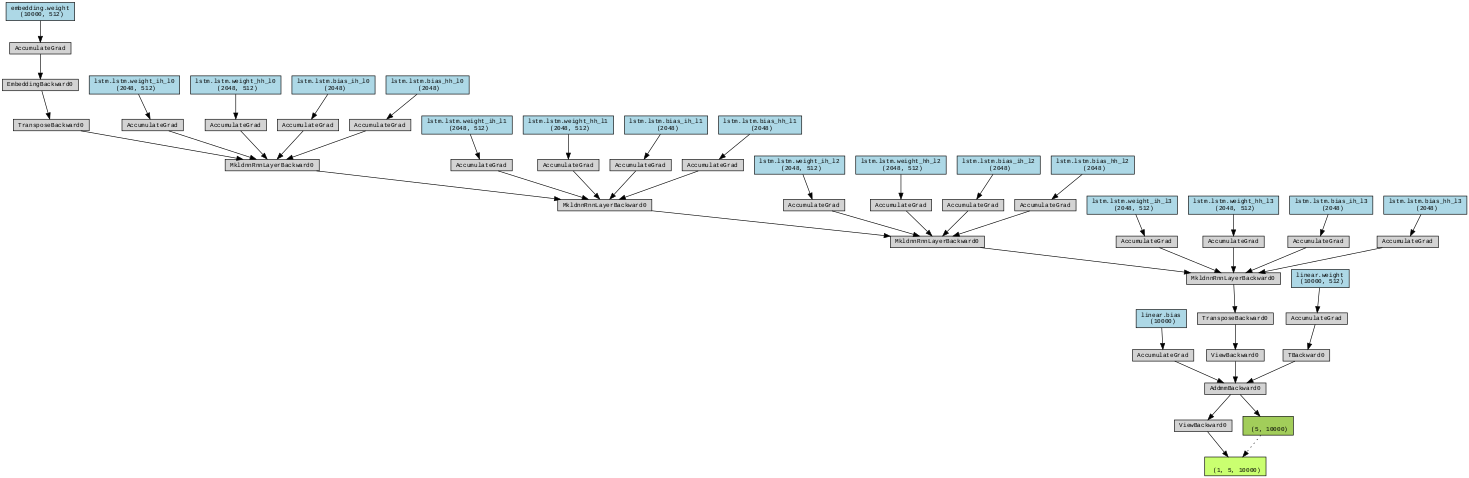

In [ ]:
import torch
from torchviz import make_dot

# Instantiate the TextGenLSTM model again
input_size = 10000
embedding_size = 512
hidden_size = 512
num_layers = 4

lstm_model_text_gen = TextGenLSTM(input_size=input_size, embedding_size=embedding_size, hidden_size=hidden_size, num_layers=num_layers)

# Create a dummy input tensor (e.g., a sequence of 5 tokens)
# The input should be long, representing token IDs, and have batch_size=1 for simplicity
dummy_input = torch.randint(0, input_size, (1, 5)) # Batch size 1, sequence length 5

# Perform a forward pass and backward pass
outputs = lstm_model_text_gen(dummy_input)

dummy_target = torch.randn_like(outputs) # Dummy target for demonstration purposes

dummy_loss = nn.MSELoss()(outputs, dummy_target)
dummy_loss.backward()

# Visualize the autograd graph using torchviz
dot = make_dot(outputs, params=dict(lstm_model_text_gen.named_parameters()))
dot.render("text_gen_autograd_tree", format="png", cleanup=True)
print("Autograd tree saved as text_gen_autograd_tree.png. Displaying it now...")

# Display the image in Colab
from IPython.display import Image
Image("text_gen_autograd_tree.png")



Answer 2c:

In [ ]:
import torch
import torch.nn as nn

#Doesn't handle layers here

class SingleGRUCell(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(SingleGRUCell, self).__init__()
    self.hidden_size = hidden_size

    # Update gate
    self.weight_ih_z = nn.Linear(input_size, hidden_size)
    self.weight_hh_z = nn.Linear(hidden_size, hidden_size)

    # Reset gate
    self.weight_ih_r = nn.Linear(input_size, hidden_size)
    self.weight_hh_r = nn.Linear(hidden_size, hidden_size)

    # New hidden state candidate
    self.weight_ih_nh = nn.Linear(input_size, hidden_size)
    self.weight_hh_nh = nn.Linear(hidden_size, hidden_size)

  def forward(self, x, h_prev):
    # x: (input)
    # h_prev: (hidden_state(t-1))

    # Update gate: sigmoid(Wzh * h(t-1) + Wzx * x(t))
    zt = torch.sigmoid(self.weight_ih_z(x) + self.weight_hh_z(h_prev))

    # Reset gate: sigmoid(Wrh * h(t-1) + Wrx * x(t))
    rt = torch.sigmoid(self.weight_ih_r(x) + self.weight_hh_r(h_prev))

    # Candidate h: tanh(Wnewh * (rt (x) h(t-1)) Wnewx * x(t))
    ht_new = torch.tanh(self.weight_ih_nh(x) + self.weight_hh_nh(rt * h_prev))

    # New hidden state (h_t)
    ht = (1 - zt) * h_prev + zt * ht_new
    return ht

In [ ]:
class MyGRU(nn.Module):
  """
    Hyperparameters:
      input_size: the number of expected features in the input
      hidden_size: the number of features in the hidden state h
      num_layers: number of recurrent layers.
  """
  def __init__(self, input_size, hidden_size, num_layers):
    super(MyGRU, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.gru_cells = nn.ModuleList()

    # num_layers has to be atleast > 0 for my code to work
    self.gru_cells.append(SingleGRUCell(input_size, hidden_size))
    for _ in range(1, num_layers):
      self.gru_cells.append(SingleGRUCell(hidden_size, hidden_size))

  def forward(self, x):

    seq_len = len(x)
    h_n = [torch.zeros(self.hidden_size) for _ in range(self.num_layers)]

    output = []
    for t in range(seq_len):
      x_t = x[t]
      h_n[0] = self.gru_cells[0](x_t, h_n[0])

      for layer in range(1,self.num_layers):
          h_n[layer] = self.gru_cells[layer](h_n[layer-1], h_n[layer])

      output.append(h_n[-1])
    return torch.stack(output, dim=0) # Stack the list of tensors into a single tensor